### How are in-demand skills trending for Data Analysts?

In [ ]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
df = load_dataset('Lukebarousse/data_jobs')
df = df['train']
df = df.to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

In [ ]:
#Filtering for job roles in India
df_DA_IND = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')].copy()

In [ ]:
df_DA_IND['job_posted_month'] = df_DA_IND['job_posted_date'].dt.month

In [ ]:
df_DA_IND_exploded = df_DA_IND.explode('job_skills')

In [ ]:
df_DA_IND_pivoted = df_DA_IND_exploded.pivot_table(index='job_posted_month', columns='job_skills', aggfunc='size')

df_DA_IND_pivoted.loc['Total'] = df_DA_IND_pivoted.sum()

df_DA_IND_sorted = df_DA_IND_pivoted[df_DA_IND_pivoted.loc['Total'].sort_values(ascending=False).index]

df_DA_IND_sorted = df_DA_IND_sorted.drop('Total', axis=0)

In [42]:
df_job_count = df_DA_IND.groupby('job_posted_month').size()

df_DA_IND_pct = df_DA_IND_sorted.div(df_job_count/100, axis=0)

df_DA_IND_pct['Month_name'] = pd.to_datetime(df_DA_IND_pct.index, format='%m').strftime('%b')

df_DA_IND_pct.set_index('Month_name', inplace=True)

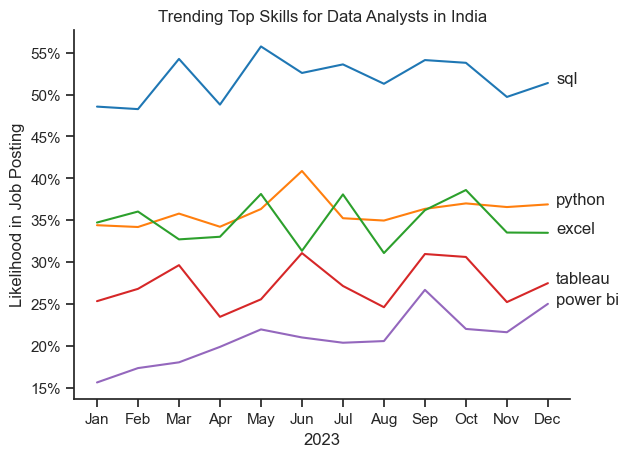

In [ ]:
df_plot = df_DA_IND_pct.iloc[:, :5]

sns.lineplot(df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=False))

for column in df_plot.columns:
    plt.text(11.2, df_plot.loc['Dec', column], column)

sns.despine()
plt.title('Trending Top Skills for Data Analysts in India')
plt.ylabel('Likelihood in Job Posting')

plt.xlabel(2023)
plt.legend().remove()
plt.show()